In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch

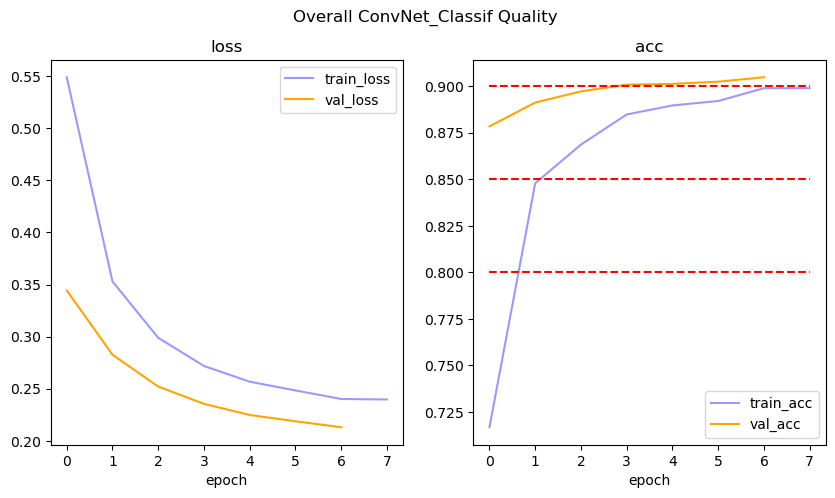

In [8]:
name = "ConvNet_Classif"
height = width = 128
data_dir = f"Logs/{name}"
subdir_name = "version_"
df = []
for i in os.listdir(data_dir):
    if i.startswith(subdir_name):
        df.append(pd.read_csv(f"{data_dir}/{i}/metrics.csv"))

metrics = pd.concat(df, axis = 0).groupby("epoch").mean()


plot_names = ["loss", "acc"]
fig = plt.figure(figsize =(5*len(plot_names), 5)) 
for i, kind in enumerate(plot_names):
    ax = fig.add_subplot(1, len(plot_names), i+1)
    metrics.loc[:, f"train_{kind}"
        ].plot(ax = ax, color = "blue", label = f"train_{kind}", alpha = 0.4)
    metrics.loc[:, f"val_{kind}"].plot(ax = ax, color = "orange", label = f"val_{kind}")
    if kind == "acc":
        ax.hlines(y = 0.80, xmin = 0, xmax = np.max(list(metrics.index)), color = "red", linestyle = "--")
        ax.hlines(y = 0.85, xmin = 0, xmax = np.max(list(metrics.index)), color = "red", linestyle = "--")
        ax.hlines(y = 0.90, xmin = 0, xmax = np.max(list(metrics.index)), color = "red", linestyle = "--")
    ax.set_xticks(np.arange(0, metrics.shape[0]))
    ax.legend()
    ax.set_title(kind)
fig.suptitle(f"Overall {name} Quality")
plt.show()